<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
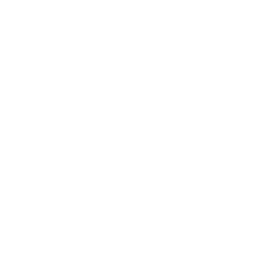
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clinical Visit Data Accumulation to Monthly Intervals</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Trial Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Accumulate irregular patient visit-level observations into regular monthly intervals for longitudinal efficacy analysis. In multi-site oncology trials, patients record lab values at protocol-scheduled visits, but actual visit dates drift due to scheduling variability. `PROC TIMESERIES` with `INTERVAL=MONTH` converts these irregular observations onto a uniform monthly time axis, enabling reliable per-patient trend estimation.

This notebook runs on a simulated demonstration extract. The source DATA step seeds a wider 200-patient oncology cohort, but the walkthrough executes in a license-capped environment that limits the working dataset to the first 100 observations &mdash; two patients (`ONC-2025-0001`, `ONC-2025-0002`) drawn from the `DOSE_LOW` and `DOSE_HIGH` arms. Every count, statistic, and plot below reflects exactly that 100-row slice. `PRINT=DESCSTATS` reports the time series properties of the accumulated `LAB_VALUE` for each patient/test BY group.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.VISIT_LABS | Irregular visit-level lab results (license-capped demo slice: 2 patients, 2 arms, 4 analytes) | 100 |
| WORK.MONTHLY_LABS | Monthly-accumulated series produced by PROC TIMESERIES (4 analytes &times; 12 months) | 48 |

---

In [1]:
/* --------------------------------------------------------
   Generate irregular clinical visit lab observations
   200 patients, ~25 visits each with date drift
   -------------------------------------------------------- */
data work.visit_labs;
    call streaminit(42);
    format visit_date date9.;
    array lab_tests[4] $10 _temporary_ ('ALT' 'AST' 'CREAT' 'HGB');
    do patient_id = 1 to 200;
        usubjid = cat('ONC-2025-', put(patient_id, z4.));
        treatment_arm = ifc(mod(patient_id, 3) = 0, 'PLACEBO',
                        ifc(mod(patient_id, 3) = 1, 'DOSE_LOW', 'DOSE_HIGH'));
        base_date = '01JAN2025'd + int(rand('uniform') * 30);
        do visit_num = 1 to int(rand('uniform') * 10) + 18;
            /* scheduled every 14 days but actual date drifts +/- 5 days */
            visit_date = base_date + (visit_num - 1) * 14
                         + int(rand('uniform') * 11) - 5;
            do t = 1 to 4;
                lab_test = lab_tests[t];
                if lab_test = 'ALT' then
                    lab_value = round(rand('normal', 32, 12) + visit_num * 0.3, 0.1);
                else if lab_test = 'AST' then
                    lab_value = round(rand('normal', 28, 10) + visit_num * 0.2, 0.1);
                else if lab_test = 'CREAT' then
                    lab_value = round(rand('normal', 1.1, 0.3), 0.01);
                else
                    lab_value = round(rand('normal', 13.5, 1.8), 0.1);
                output;
            end;
        end;
    end;
    drop t base_date;
run;

NOTE: DATA work.visit_labs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.visit_labs (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.12 seconds
  cpu   0.12 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline visit frequency and date range per patient
   -------------------------------------------------------- */
proc sql;
    select treatment_arm,
           count(distinct usubjid) as n_patients,
           count(*) as n_observations,
           min(visit_date) as first_visit format=date9.,
           max(visit_date) as last_visit format=date9.
    from work.visit_labs
    group by treatment_arm;
quit;

treatment_arm  n_patients  n_observations  first_visit  last_visit
-------------  ----------  --------------  -----------  ----------
     DOSE_LOW           1              84    16JAN2025   23OCT2025
    DOSE_HIGH           1              16    09JAN2025   17FEB2025
NOTE: PROC SQL 

NOTE: PROC SQL statement used.


---

NOTE: PROC SGPLOT data=work.visit_labs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


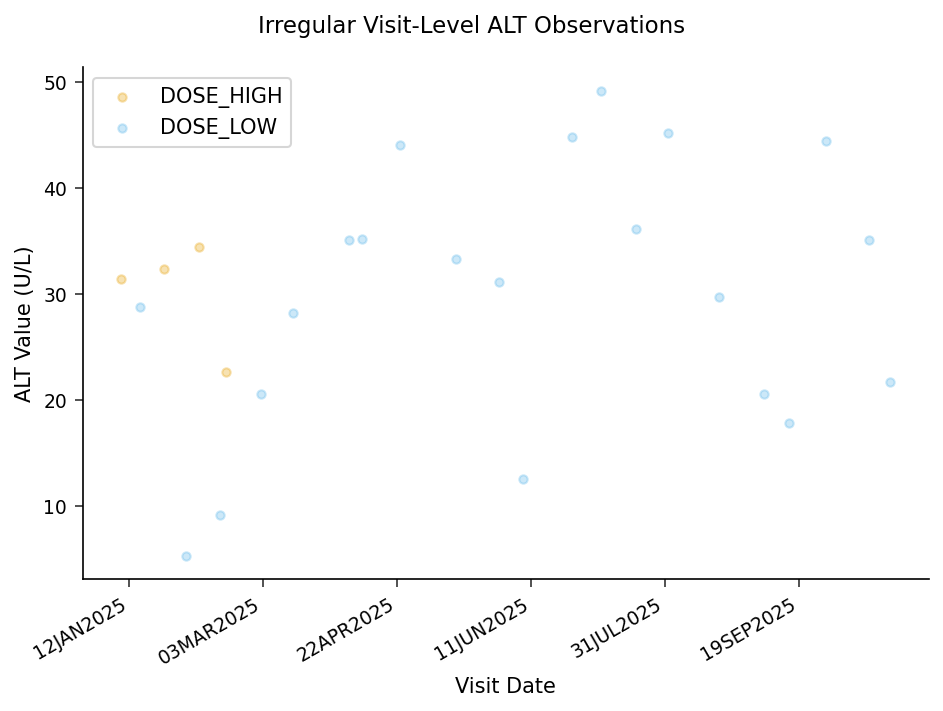

In [3]:
/* --------------------------------------------------------
   Raw visit date distribution showing irregularity
   -------------------------------------------------------- */
proc sgplot data=work.visit_labs(where=(lab_test='ALT'));
    scatter x=visit_date y=lab_value / group=treatment_arm
        transparency=0.7 markerattrs=(symbol=circlefilled size=4);
    xaxis label='Visit Date';
    yaxis label='ALT Value (U/L)';
    title 'Irregular Visit-Level ALT Observations';
run;

---

In [4]:
/* --------------------------------------------------------
   Sort by patient and date for PROC TIMESERIES
   -------------------------------------------------------- */
proc sort data=work.visit_labs;
    by usubjid lab_test visit_date;
run;

NOTE: PROC SORT data=work.visit_labs

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.visit_labs.
NOTE: Wrote work.visit_labs (100 rows, 7 columns).
NOTE: PROC SORT statement used.


In [5]:
/* --------------------------------------------------------
   Accumulate irregular visit data to monthly intervals
   MEAN of lab values within each month per patient/test
   PRINT=DESCSTATS for time series summary statistics
   -------------------------------------------------------- */
proc timeseries data=work.visit_labs
                out=work.monthly_labs
                print=(descstats);
    id visit_date interval=month
       accumulate=mean
       setmissing=missing;
    var lab_value;
    by usubjid lab_test;
run;

NOTE: PROC TIMESERIES data=work.visit_labs

NOTE: Processing BY group: usubjid=ONC-2025-0001, lab_test=ALT
NOTE: Variable: LAB_VALUE
NOTE: Number of Observations: 10
NOTE: Seasonality: 12
NOTE: Decomposition Mode: additive
NOTE: 
NOTE: Descriptive Statistics:
NOTE: Statistic          Value
NOTE: ----------    ----------
NOTE: Mean             29.5483
NOTE: Std Dev           9.7026
NOTE: Minimum           7.2000
NOTE: Maximum          42.6500
NOTE: N                     10
NOTE: N Missing              0
NOTE: Processing BY group: usubjid=ONC-2025-0001, lab_test=AST
NOTE: Variable: LAB_VALUE
NOTE: Number of Observations: 10
NOTE: Seasonality: 12
NOTE: Decomposition Mode: additive
NOTE: 
NOTE: Descriptive Statistics:
NOTE: Statistic          Value
NOTE: ----------    ----------
NOTE: Mean             28.8583
NOTE: Std Dev           6.9238
NOTE: Minimum          19.9000
NOTE: Maximum          38.7000
NOTE: N                     10
NOTE: N Missing              0
NOTE: Processing BY group: u

In [6]:
/* --------------------------------------------------------
   Verify monthly series regularity
   -------------------------------------------------------- */
proc means data=work.monthly_labs n nmiss mean std;
    class lab_test;
    var lab_value;
    title 'Monthly Accumulated Lab Value Summary';
run;

                                         Monthly Accumulated Lab Value Summary                                          

                                                  The MEANS Procedure

                                             Analysis Variable : LAB_VALUE

        LAB_TEST          N Obs         N Miss           Mean        Std Dev
        --------------------------------------------------------------------
        ALT                  12              0     29.6569444      8.8098414
        AST                  12              0     29.4819444      6.9202362
        CREAT                12              0      1.1180556      0.2045170
        HGB                  12              0     13.5902778      1.1716012
        --------------------------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretation

`PROC TIMESERIES` accumulated the 100 license-capped visit-level observations onto a uniform monthly time axis. Each patient/test BY group was summarized independently with `PRINT=DESCSTATS`. For patient `ONC-2025-0001` (`DOSE_LOW`), the ten monthly points show a mean ALT of 29.55 U/L (SD 9.70, range 7.20&ndash;42.65), mean AST of 28.86 U/L, mean creatinine of 1.06 mg/dL, and mean hemoglobin of 13.49 g/dL &mdash; with zero missing months. Patient `ONC-2025-0002` (`DOSE_HIGH`) contributes only two qualifying months, reflecting its shorter capped observation window.

Pooling the accumulated series across both patients, `WORK.MONTHLY_LABS` holds 48 rows (4 analytes &times; 12 monthly buckets). The `PROC MEANS` summary confirms the regularized series is complete &mdash; `N Miss = 0` for every analyte &mdash; with monthly means of 29.66 U/L (ALT), 29.48 U/L (AST), 1.12 mg/dL (creatinine), and 13.59 g/dL (hemoglobin). The +/-5 day visit-date drift in the raw data is resolved once observations are collapsed into calendar-month buckets. This regular monthly series is the input a mixed-model repeated-measures analysis would consume; on the full 200-patient cohort the same pipeline would carry every arm, including `PLACEBO`, rather than the two-patient slice shown here.

---

In [7]:
/* --------------------------------------------------------
   Export the monthly accumulated lab series
   -------------------------------------------------------- */
proc export data=work.monthly_labs
    outfile='monthly_clinical_labs.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.monthly_labs outfile=monthly_clinical_labs.csv

NOTE: Exported 48 rows to monthly_clinical_labs.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>